In [76]:
import glob
import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
from astropy.io import fits
from tqdm import tqdm

In [2]:
glob.glob('/data3/thomasli/selfcal/old_euclid_outputs/*')

['/data3/thomasli/selfcal/old_euclid_outputs/EDFN_H_0p6arcsec_coadd.fits',
 '/data3/thomasli/selfcal/old_euclid_outputs/EDFN_J_0p6arcsec_coadd.fits',
 '/data3/thomasli/selfcal/old_euclid_outputs/EDFN_Y_0p6arcsec_coadd.fits',
 '/data3/thomasli/selfcal/old_euclid_outputs/footprint.npy',
 '/data3/thomasli/selfcal/old_euclid_outputs/nep_full_6arcsec_RGB_processed.fits',
 '/data3/thomasli/selfcal/old_euclid_outputs/nep_full_H_3arcsec_10chunk_fit.h5',
 '/data3/thomasli/selfcal/old_euclid_outputs/nep_full_H_3arcsec_20chunk_fit.h5',
 '/data3/thomasli/selfcal/old_euclid_outputs/nep_full_H_3arcsec_40chunk_fit.h5',
 '/data3/thomasli/selfcal/old_euclid_outputs/nep_full_H_6arcsec_coadd.fits',
 '/data3/thomasli/selfcal/old_euclid_outputs/nep_full_H_6arcsec_coadd.npy',
 '/data3/thomasli/selfcal/old_euclid_outputs/nep_full_H_6arcsec_fit.h5',
 '/data3/thomasli/selfcal/old_euclid_outputs/nep_full_H_6arcsec_footprint.npy',
 '/data3/thomasli/selfcal/old_euclid_outputs/nep_full_H_6arcsec_subframe_coords.np

In [6]:
cal_file = '/data3/thomasli/selfcal/old_euclid_outputs/nep_full_H_3arcsec_40chunk_fit.h5'
with h5py.File(cal_file, 'r') as hf:
    D = hf['D'][:]

In [20]:
from scipy.interpolate import RectBivariateSpline
def mean_preserving_spline_2d(x_edges, y_edges, z_means, kx=3, ky=3):
    """
    Generates a mean-preserving spline function f(x, y) based on 2D grid edges
    and the average value z_mean in each rectangular cell.

    The function f(x, y) is constructed as the mixed partial derivative of a 
    bicubic spline F(x, y), where F(x, y) is the double integral of f(x, y).

    Parameters
    ----------
    x_edges : array_like, shape (N+1,)
        The edges of the bins along the x-axis.
    y_edges : array_like, shape (M+1,)
        The edges of the bins along the y-axis.
    z_means : array_like, shape (N, M)
        The mean value of the function within each rectangular bin.
    kx, ky : int, optional
        The degrees of the spline in x and y directions. Default is 3 (bicubic).
        
    Returns
    -------
    f_spline : callable
        A function f(x, y, grid=False) that evaluates the interpolated density.
        - If grid=True, evaluates on the grid spanned by x and y vectors.
        - If grid=False, evaluates at coordinates (x, y).
    """
    x_edges = np.asarray(x_edges, dtype=float)
    y_edges = np.asarray(y_edges, dtype=float)
    z_means = np.asarray(z_means, dtype=float)

    # 1. Validation
    if x_edges.shape[0] != z_means.shape[0] + 1:
        raise ValueError("len(x_edges) must be len(z_means) + 1 (rows)")
    if y_edges.shape[0] != z_means.shape[1] + 1:
        raise ValueError("len(y_edges) must be z_means.shape[1] + 1 (cols)")

    # 2. Compute Interval Areas (Volumes)
    # dx: (N,) -> column vector (N, 1)
    # dy: (M,) -> row vector (1, M)
    dx = np.diff(x_edges)
    dy = np.diff(y_edges)
    
    # Calculate volume of each cell: z_mean * dx * dy
    # Broadcasting: (N, 1) * (1, M) * (N, M)
    cell_volumes = z_means * dx[:, None] * dy[None, :]

    # 3. Compute Cumulative Integrals (2D Cumulative Sum)
    # The integral at (x0, y0) is 0.
    # The integral at (xi, yj) is sum of volumes in rect defined by [0:i, 0:j]
    integral_grid = np.zeros((len(x_edges), len(y_edges)))
    
    # cumsum over x (axis 0), then over y (axis 1)
    cumulative_volumes = np.cumsum(np.cumsum(cell_volumes, axis=0), axis=1)
    
    # Fill the integral grid (row 0 and col 0 remain 0s)
    integral_grid[1:, 1:] = cumulative_volumes

    # 4. Interpolate the Integral Surface F(x, y)
    # RectBivariateSpline creates a smooth surface over the regular grid
    F_spline = RectBivariateSpline(x_edges, y_edges, integral_grid, kx=kx, ky=ky)

    # 5. Define the Density Function
    # f(x, y) = d^2 F / dx dy
    # RectBivariateSpline allows calculating partial derivatives directly.
    
    def f_spline(x, y, grid=False):
        """
        Evaluate the mean-preserving spline.
        grid=True: x and y are vectors defining a grid.
        grid=False: x and y are coordinates of points.
        """
        # Calculate mixed partial derivative (dx=1, dy=1)
        return F_spline(x, y, dx=1, dy=1, grid=grid)

    return f_spline

In [36]:
x_edges = np.linspace(0, 2040, 40+1)
y_edges = np.linspace(0, 2040, 40+1)
z_means = D[0]

In [51]:
spl = mean_preserving_spline_2d(x_edges, y_edges, z_means, kx=2, ky=2)

In [53]:
fine_D = spl(X_fine, Y_fine, grid=True)

In [54]:
fine_D.shape

(2040, 2040)

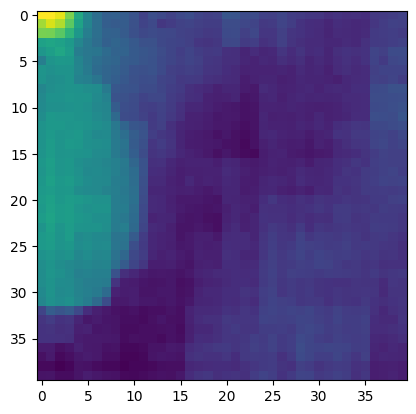

In [55]:
plt.imshow(D[0])

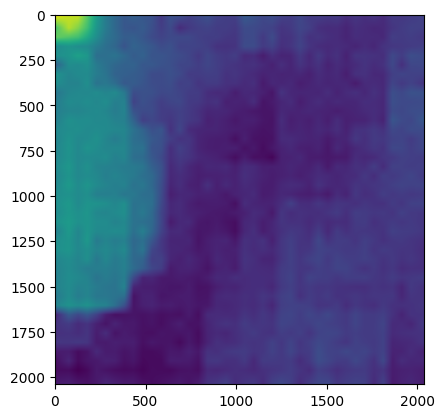

In [56]:
plt.imshow(fine_D, cmap='viridis')

In [89]:
back_dir = '/data1/Euclid/OTF/Background/'
back_files = sorted(glob.glob(back_dir+'*_H*.fits'))

bg_sum = np.zeros((2040, 2040))
num = 0
for f in tqdm(back_files[0:100]):
    try:
        with fits.open(f) as hdul:
            bg_sum += hdul[1].data
            num += 1
    except Exception as e:
        print(f"Error processing file {f}: {e}")

bg_mean = bg_sum / num

 33%|████████████████████████████████████▎                                                                         | 33/100 [00:02<00:04, 13.89it/s]

Error processing file /data1/Euclid/OTF/Background/EUC_NIR_W-CAL-IMAGE-BKG_H-2039-2_20240706T085345.197149Z.fits: No SIMPLE card found, this file does not appear to be a valid FITS file. If this is really a FITS file, try with ignore_missing_simple=True


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:07<00:00, 12.92it/s]


In [136]:
from SelfCal.MapHelper import bin2d_cv, upscale2d

In [154]:
mock_D = np.clip(bg_mean, a_min=None, a_max=np.percentile(bg_mean, 99))

bin_num = 60
bin_factor = 2040 // bin_num
mock_D_descretized = bin2d_cv(mock_D, bin_factor)

In [155]:
spl = mean_preserving_spline_2d(
    np.linspace(0, 2040, bin_num+1),
    np.linspace(0, 2040, bin_num+1),
    mock_D_descretized, kx=2, ky=2)

mock_D_recovered = spl(np.arange(2040), np.arange(2040), grid=True)
mock_D_recovered_naive = upscale2d(mock_D_descretized, bin_factor)

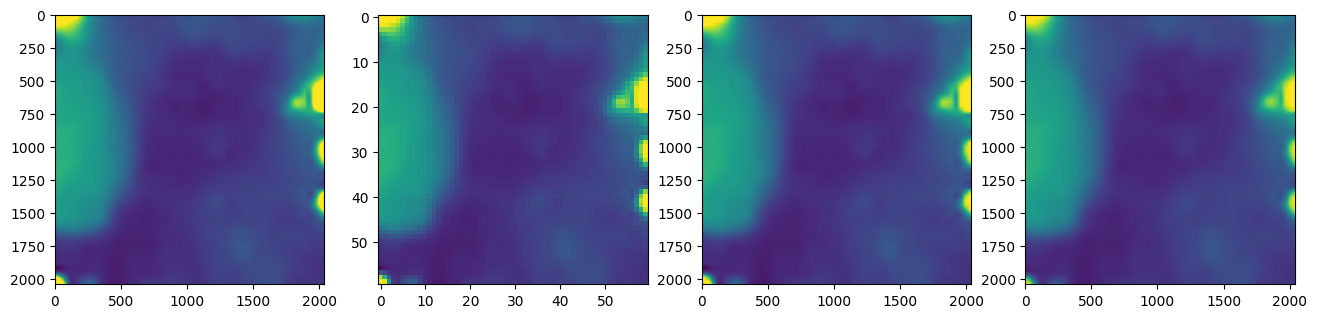

In [165]:
vmin=mock_D.min()
vmax=mock_D.max()

fig = plt.figure(figsize=(16,4))
plt.subplot(1,4,1)
plt.imshow(mock_D, cmap='viridis', vmin=vmin, vmax=vmax)
plt.subplot(1,4,2)
plt.imshow(mock_D_descretized, cmap='viridis', vmin=vmin, vmax=vmax)
plt.subplot(1,4,3)
plt.imshow(mock_D_recovered, cmap='viridis', vmin=vmin, vmax=vmax)
plt.subplot(1,4,4)
plt.imshow(mock_D_recovered_naive, cmap='viridis', vmin=vmin, vmax=vmax)

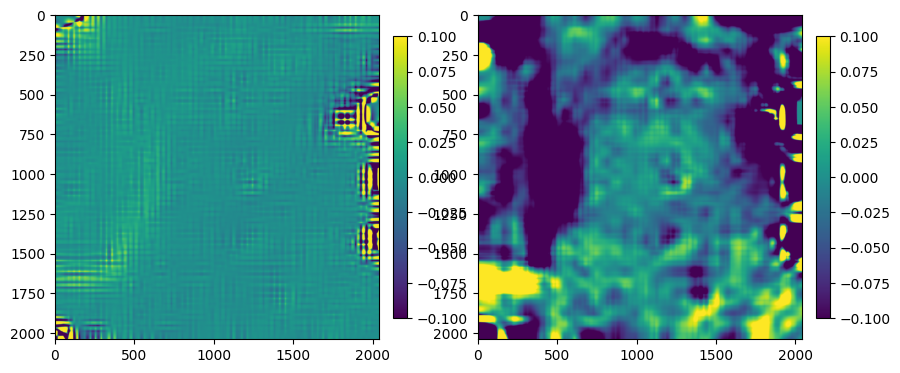

In [ ]:
error = (mock_D_recovered - mock_D)/mock_D*100
error_naive = (mock_D_recovered_naive - mock_D)/mock_D*100

fig = plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
im = plt.imshow(error, cmap='viridis', vmin=-0.1, vmax=0.1)
plt.colorbar(im, ax=plt.gca(), orientation='vertical', fraction=0.040, pad=0.04)
plt.subplot(1,2,2)
im = plt.imshow(error_naive, cmap='viridis', vmin=-0.1, vmax=0.1)
plt.colorbar(im, ax=plt.gca(), orientation='vertical', fraction=0.040, pad=0.04)
